# Photometry before / after — overlaid

Original CNN and aperture + CNN appear **on the same axes**. Solid lines show
running medians and shaded bands show the **16th–84th percentiles of source residuals**,
not confidence intervals on the median.

The expanded sample uses all available Q1 tiles in the **original test RA region**,
retaining its 30-arcsec guard. Both saved models remain frozen; training and validation
IDs are excluded. Sources brighter than magnitude 20 are excluded from both plotting
and running statistics. This notebook reads predictions and does not retrain models.

Two **no-CNN** controls are included: a single background-subtracted 1.5″ aperture
with one scalar calibration fitted on training sources, and the training-calibrated
combination of three aperture sums used to initialize the new model. The latter
isolates what the CNN correction adds. Neither calibration uses held-out labels.
A final plot measures the correction itself.

In [1]:
from pathlib import Path
import csv
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import display

# Works when launched from this directory or the JAISP repository root.
candidates = [Path.cwd(), Path.cwd() / "models/photometry/simple_regressor_review"]
BASE = next((p for p in candidates if (p / "simple_regressor").is_dir()), None)
if BASE is None:
    raise FileNotFoundError("Launch from the JAISP root or simple_regressor_review directory")

BEFORE_CSV = BASE / "runs/q1_expanded_holdout/predictions_before.csv"
AFTER_CSV = BASE / "runs/q1_expanded_holdout/predictions_after.csv"
OUTPUT_DIR = BASE / "runs/plots"
WINDOW = 101                 # consecutive sources, ordered by reference magnitude
ZEROPOINT = 23.9             # AB magnitude for flux in microJy
REQUIRE_IDENTICAL_IDS = True
MIN_MAG = 20.0              # exclude brighter sources from plots AND running windows
MAG_LIMITS = (20, None)      # display range
SHOW_POINTS = False         # turn on individual residuals beneath the bands
DMAG_LIMITS = None           # e.g. (-0.6, 0.6); None includes every residual
PERCENT_LIMITS = None        # e.g. (-60, 100); None includes every residual
SAVE = True                 # export PNG and PDF, overwriting the named plot files

plt.rcParams.update({"font.size": 11, "axes.spines.top": False,
                     "axes.spines.right": False})

## Load and align the predictions

Object IDs stay as strings to avoid losing precision. Both models must have the
same reference fluxes. By default, different source lists raise an error; disabling
`REQUIRE_IDENTICAL_IDS` explicitly compares their intersection and reports exclusions.

In [2]:
def read_predictions(path):
    if not path.exists():
        raise FileNotFoundError(f"Missing predictions: {path}. Run evaluation first.")
    with path.open(newline="") as f:
        rows = list(csv.DictReader(f))
    required = {"object_id", "flux_true_ujy", "flux_pred_ujy"}
    if not rows or not required.issubset(rows[0]):
        raise ValueError(f"Empty CSV or missing columns {required}: {path}")
    table = {row["object_id"]: row for row in rows}
    if len(table) != len(rows):
        raise ValueError(f"Duplicate object IDs in {path}")
    return table

before = read_predictions(BEFORE_CSV)
after = read_predictions(AFTER_CSV)
if REQUIRE_IDENTICAL_IDS and before.keys() != after.keys():
    raise ValueError("Source lists differ. Select matching runs or explicitly allow intersection.")
ids = sorted(before.keys() & after.keys())
if not ids:
    raise ValueError("No common sources")
print(f"Common sources: {len(ids)}; before-only: {len(before)-len(ids)}; after-only: {len(after)-len(ids)}")

reference = np.array([float(before[k]["flux_true_ujy"]) for k in ids])
reference_after = np.array([float(after[k]["flux_true_ujy"]) for k in ids])
if not np.allclose(reference, reference_after, rtol=1e-5, atol=1e-8, equal_nan=True):
    raise ValueError("Reference fluxes differ: check the target definition and catalogs")
predictions = np.array([
    [float(before[k]["flux_pred_ujy"]) for k in ids],
    [float(after[k]["flux_pred_ujy"]) for k in ids],
    [float(after[k]["aperture_flux_ujy"]) for k in ids],
    [float(after[k]["single_aperture_flux_ujy"]) for k in ids],
])
LABELS = ["Original CNN", "Aperture + CNN", "Three apertures, no CNN", "Single 1.5″ aperture, no CNN"]
valid = np.isfinite(reference) & (reference > 0) & np.isfinite(predictions).all(axis=0)
print(f"Excluded invalid references/predictions: {(~valid).sum()}")
reference, predictions = reference[valid], predictions[:, valid]
if not len(reference):
    raise ValueError("No finite positive reference fluxes")
magnitude = ZEROPOINT - 2.5 * np.log10(reference)
in_range = magnitude >= MIN_MAG
print(f"Excluded brighter than {MIN_MAG:g} mag: {(~in_range).sum()}")
reference, predictions, magnitude = reference[in_range], predictions[:, in_range], magnitude[in_range]
positive = (predictions > 0).all(axis=0)
for label, pred in zip(LABELS, predictions):
    print(f"Nonpositive predictions: {label}: {(pred <= 0).sum()}")
print(f"Magnitude plots use {positive.sum()} common positive sources; flux plots use {len(reference)} sources")

fractional_percent = 100 * (predictions - reference[None]) / reference[None]
delta_mag = -2.5 * np.log10(predictions[:, positive] / reference[None, positive])

Common sources: 2712; before-only: 0; after-only: 0
Excluded invalid references/predictions: 0
Excluded brighter than 20 mag: 54
Nonpositive predictions: Original CNN: 0
Nonpositive predictions: Aperture + CNN: 0
Nonpositive predictions: Three apertures, no CNN: 41
Nonpositive predictions: Single 1.5″ aperture, no CNN: 57
Magnitude plots use 2601 common positive sources; flux plots use 2658 sources


## Plot helper

Each window contains the same sources for both models. Its horizontal coordinate
is the median reference magnitude. Windows overlap, so adjacent plotted points
are correlated. Curves stop where a full window is unavailable; sparse bright and
faint tails are not extrapolated. Optional axis limits affect the display only.

In [3]:
def nmad(values):
    return 1.4826 * np.median(np.abs(values - np.median(values)))


def running_distribution(x, residuals, window):
    if not isinstance(window, int) or window < 3 or window > len(x):
        raise ValueError(f"WINDOW must be an integer between 3 and {len(x)}")
    order = np.argsort(x, kind="stable")
    windows = np.lib.stride_tricks.sliding_window_view(order, window)
    centers = np.median(x[windows], axis=1)
    # [model, percentile, window]
    quantiles = np.stack([np.percentile(y[windows], [16, 50, 84], axis=1)
                          for y in residuals])
    return centers, quantiles


def plot_before_after(x, residuals, ylabel, unit, name, limits=None):
    centers, quantiles = running_distribution(x, residuals, WINDOW)
    fig, ax = plt.subplots(figsize=(10.5, 6))
    colors = ["#b65b35", "#167b94", "#7654a3", "#56833e"]
    labels = LABELS
    summaries = []
    for i, (y, color, label) in enumerate(zip(residuals, colors, labels)):
        low, median, high = quantiles[i]
        if SHOW_POINTS:
            ax.scatter(x, y, s=8, color=color, alpha=.08, edgecolors="none", rasterized=True)
        ax.fill_between(centers, low, high, color=color, alpha=.20)
        ax.plot(centers, median, color=color, lw=2.5, label=label,
                linestyle=["--", "-", "-.", ":"][i])
        summaries.append(f"{label}: median {np.median(y):+.3f}, NMAD {nmad(y):.3f} {unit}")
    ax.axhline(0, color="#353535", ls=":", lw=1)
    ax.set_xlabel("MER VIS aperture magnitude [AB]")
    ax.set_ylabel(ylabel)
    ax.grid(alpha=.16)
    if limits is None:
        visible = residuals if SHOW_POINTS else quantiles[:, (0, 2), :]
        pad = .1 * max(float(np.ptp(visible)), .1)
        limits = (min(float(visible.min()), 0) - pad, max(float(visible.max()), 0) + pad)
    ax.set_ylim(limits)
    if MAG_LIMITS is not None:
        ax.set_xlim(MAG_LIMITS)
    ax.legend(loc="best", fontsize=11)
    ax.set_title("VIS photometry: before and after", fontsize=15, fontweight="bold", pad=14)
    fig.text(.5, .045, f"{len(x):,} common held-out sources, magnitude ≥ {MIN_MAG:g} • Running window: {WINDOW} sources\n"
             "Shaded regions: central 68% of residuals (16th–84th percentiles)",
             ha="center", fontsize=10, color="#444444")
    fig.tight_layout(rect=(0, .10, 1, 1))
    for summary in summaries:
        print(summary)
    if SAVE:
        OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
        for extension in ("png", "pdf"):
            path = OUTPUT_DIR / f"{name}_overlay.{extension}"
            fig.savefig(path, dpi=180, bbox_inches="tight")
            print(path)
    display(fig)
    plt.close(fig)
    return centers, quantiles

## Magnitude residuals

$\Delta m = m_\mathrm{predicted} - m_\mathrm{MER} = -2.5\log_{10}(F_\mathrm{predicted}/F_\mathrm{MER})$.
A negative residual means the predicted source is too bright.

Original CNN: median -0.026, NMAD 0.161 mag
Aperture + CNN: median -0.012, NMAD 0.135 mag
Three apertures, no CNN: median +0.029, NMAD 0.232 mag
Single 1.5″ aperture, no CNN: median -0.014, NMAD 0.211 mag


/home/shemmati/Work/Projects/JAISP/models/photometry/simple_regressor_review/runs/plots/before_after_magnitude_overlay.png


/home/shemmati/Work/Projects/JAISP/models/photometry/simple_regressor_review/runs/plots/before_after_magnitude_overlay.pdf


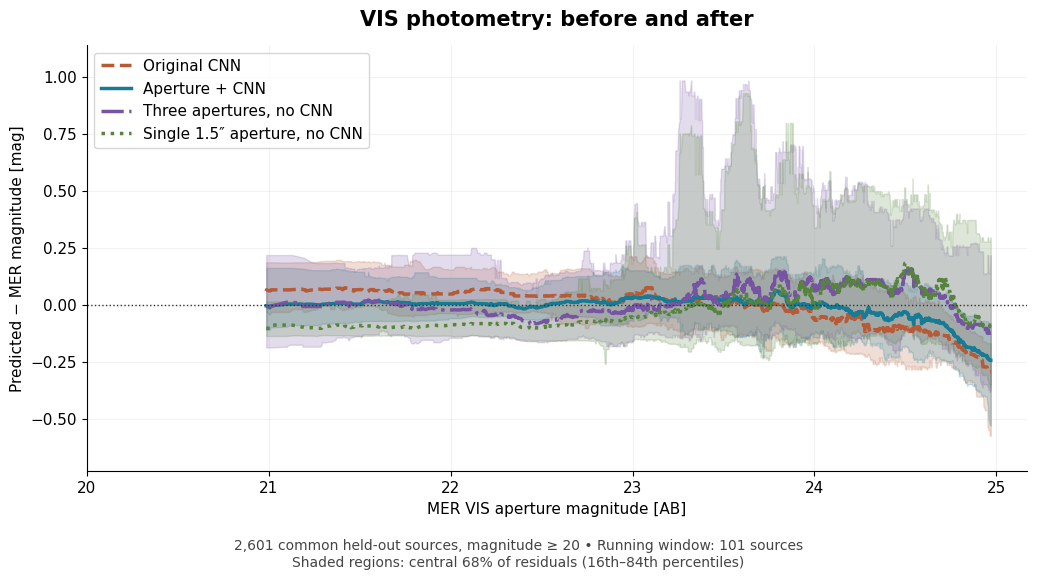

In [4]:
mag_centers, mag_quantiles = plot_before_after(
    magnitude[positive], delta_mag, "Predicted − MER magnitude [mag]", "mag",
    "before_after_magnitude", DMAG_LIMITS)

## Fractional flux residuals

$100(F_\mathrm{predicted}-F_\mathrm{MER})/F_\mathrm{MER}$.
A positive residual means the predicted flux is too high. Unlike magnitude
residuals, this plot includes finite zero or negative predictions.

Original CNN: median +2.746, NMAD 15.305 %
Aperture + CNN: median +1.268, NMAD 12.847 %
Three apertures, no CNN: median -3.277, NMAD 21.901 %
Single 1.5″ aperture, no CNN: median +0.662, NMAD 20.933 %
/home/shemmati/Work/Projects/JAISP/models/photometry/simple_regressor_review/runs/plots/before_after_fractional_flux_overlay.png


/home/shemmati/Work/Projects/JAISP/models/photometry/simple_regressor_review/runs/plots/before_after_fractional_flux_overlay.pdf


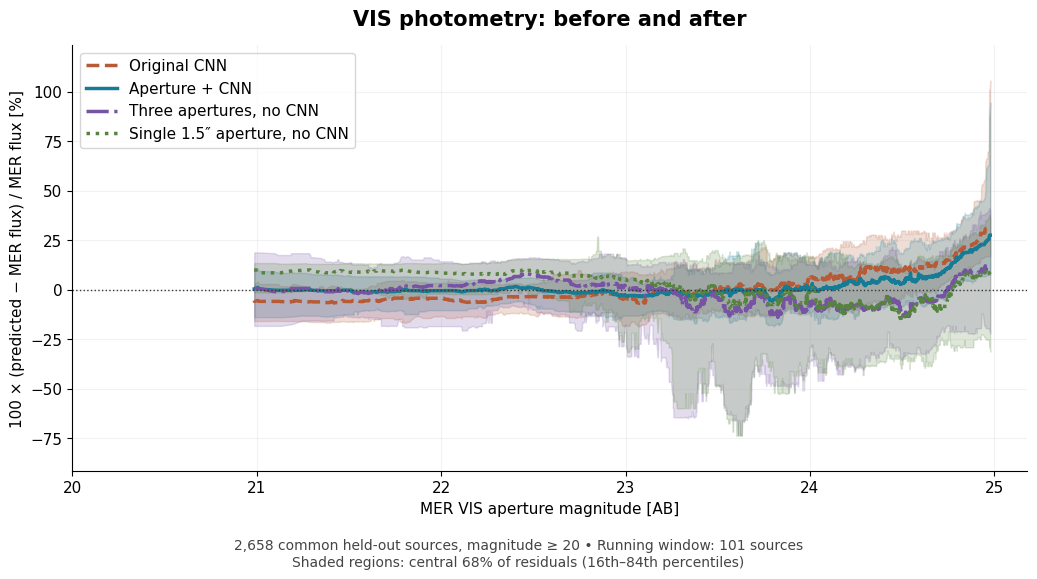

In [5]:
flux_centers, flux_quantiles = plot_before_after(
    magnitude, fractional_percent, "100 × (predicted − MER flux) / MER flux [%]", "%",
    "before_after_fractional_flux", PERCENT_LIMITS)

## Is the CNN correction doing anything?

Compare the corrected prediction to its **own three-aperture initialization**.
The plotted quantity is $100(F_\mathrm{CNN}-F_\mathrm{aperture})/F_\mathrm{MER}$;
zero everywhere would mean no correction. This uses all finite predictions,
including negative aperture estimates. It also reports the fraction of corrections
smaller than 0.1% of the reference flux. A nonzero correction alone does not establish
improvement: compare the errors against MER on the preceding plots.

The printed correction-size statistics use positive aperture initializations to isolate
the learned change. For negative aperture estimates, the plotted flux difference also
includes the positive floor used by the log-flux model.


Positive aperture initializations used to measure the learned correction: 2617
Median absolute CNN correction: 10.011% of MER flux
Corrections smaller than 0.1% of MER flux: 0.50%
Flux metrics on identical objects (including nonpositive aperture estimates):
Original CNN                     bias=+2.746%  NMAD=15.305%  median absolute error=9.984%
Aperture + CNN                   bias=+1.268%  NMAD=12.847%  median absolute error=8.362%
Three apertures, no CNN          bias=-3.277%  NMAD=21.901%  median absolute error=14.158%
Single 1.5″ aperture, no CNN     bias=+0.662%  NMAD=20.933%  median absolute error=14.248%


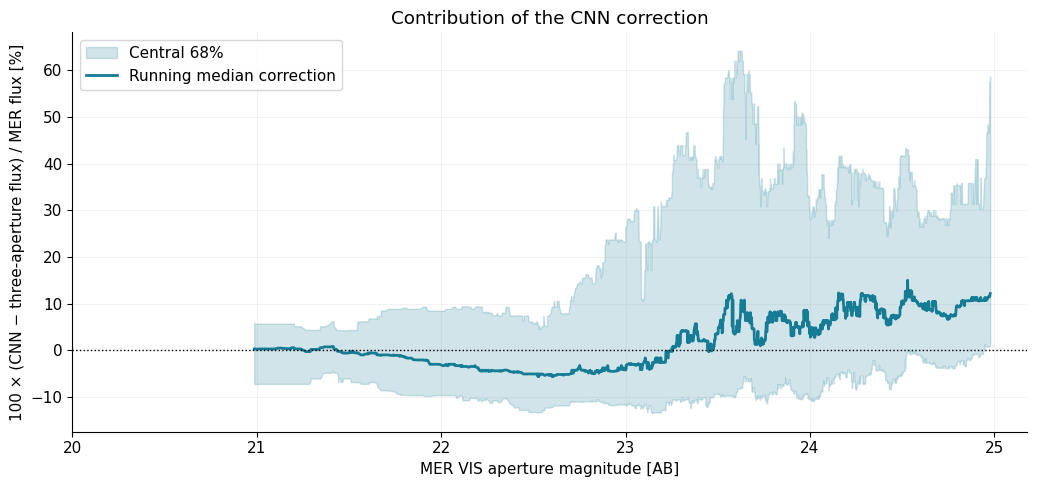

In [6]:
correction = 100 * (predictions[1] - predictions[2]) / reference
positive_base = predictions[2] > 0
print(f"Positive aperture initializations used to measure the learned correction: {positive_base.sum()}")
print(f"Median absolute CNN correction: {np.median(np.abs(correction[positive_base])):.3f}% of MER flux")
print(f"Corrections smaller than 0.1% of MER flux: {np.mean(np.abs(correction[positive_base]) < .1):.2%}")
print("Flux metrics on identical objects (including nonpositive aperture estimates):")
for label, residual in zip(LABELS, fractional_percent):
    print(f"{label:32s} bias={np.median(residual):+.3f}%  NMAD={nmad(residual):.3f}%  "
          f"median absolute error={np.median(np.abs(residual)):.3f}%")
xc, qq = running_distribution(magnitude, correction[None], WINDOW)
lo, med, hi = qq[0]
fig, ax = plt.subplots(figsize=(10.5, 5))
ax.fill_between(xc, lo, hi, color="#167b94", alpha=.2, label="Central 68%")
ax.plot(xc, med, color="#167b94", lw=2, label="Running median correction")
ax.axhline(0, color="black", ls=":", lw=1)
ax.set(xlabel="MER VIS aperture magnitude [AB]",
       ylabel="100 × (CNN − three-aperture flux) / MER flux [%]",
       title="Contribution of the CNN correction")
ax.set_xlim(MAG_LIMITS)
ax.grid(alpha=.16); ax.legend()
fig.tight_layout()
if SAVE:
    for extension in ("png", "pdf"):
        fig.savefig(OUTPUT_DIR / f"cnn_correction.{extension}", dpi=180, bbox_inches="tight")
display(fig); plt.close(fig)

## Interpretation and provenance

Running windows contain the same sources for both models and only sources at or
fainter than `MIN_MAG`. Full windows are required, so curves do not extend into
undersampled tails. Bands represent the residual distribution, not uncertainty
on the median. With `SHOW_POINTS=False`, axes fit the bands; individual outliers
remain in statistics but are not drawn.

The frozen checkpoints were chosen on the original validation set. Expanding the
**existing test region** increases evaluation sources without moving the sky split
or reusing training/validation sources. See `runs/q1_expanded_holdout/metadata.json`
for the exact boundary and exclusions. This remains one field and one training
seed; MER catalog fluxes are references, not injection truth.

To regenerate the expanded predictions from this directory:
```bash
python -m simple_regressor.expand_holdout \
  --before-dir runs/q1_v1_control \
  --after-dir runs/q1_v2_pilot \
  --output runs/q1_expanded_holdout
```